# 04c Strict Equal-Ground Comparison (Post-Run)

Use this notebook **after** `04_fair_play_model_comparison.ipynb`.

Why this exists:
- classical and boosting pipelines can produce different raw test row counts
- this notebook enforces identical evaluation points across all models
- output is a strict apples-to-apples leaderboard for decision making


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path('/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling')
SCRIPTS = ROOT / 'scripts'
REPORTS = ROOT / 'outputs' / 'reports'
CLEAN_PATH = ROOT / 'outputs' / 'cleaned' / 'dataset_p_clean.csv'

sys.path.insert(0, str(SCRIPTS))
from common import summarize_metrics, get_split_dates

FORECASTS_PATH = REPORTS / 'portable_fair_play_p_forecasts.csv'
assert FORECASTS_PATH.exists(), f'Missing forecasts file: {FORECASTS_PATH}. Run notebook 04 first.'
assert CLEAN_PATH.exists(), f'Missing cleaned dataset: {CLEAN_PATH}'
print('Using forecasts:', FORECASTS_PATH)

Using forecasts: /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/portable_fair_play_p_forecasts.csv


In [2]:
fc = pd.read_csv(FORECASTS_PATH)
fc['month'] = pd.to_datetime(fc['month'])

ref_model_candidates = ['ARIMA', 'ETS', 'SARIMA']
ref_model = next((m for m in ref_model_candidates if m in fc['model'].unique()), None)
if ref_model is None:
    raise RuntimeError('No classical reference model found in forecasts; cannot build strict alignment grid.')

ref_grid = (
    fc[(fc['split'] == 'test') & (fc['model'] == ref_model)][['horizon', 'month']]
    .drop_duplicates()
    .sort_values(['horizon', 'month'])
)

strict_test = (
    fc[fc['split'] == 'test']
    .merge(ref_grid, on=['horizon', 'month'], how='inner')
    .copy()
)

nobs_check = strict_test.groupby(['model', 'horizon']).size().unstack(fill_value=0)
nobs_check.head()

horizon,1,2,3,4,5,6,7,8,9,10,11,12
model,,,,,,,,,,,,
ARIMA,288,288,288,288,288,288,288,288,288,288,288,288
CATBOOST,288,288,288,288,288,288,288,288,288,288,288,288
ETS,288,288,288,288,288,288,288,288,288,288,288,288
LIGHTGBM,288,288,288,288,288,288,288,288,288,288,288,288
RANDOM_FOREST,288,288,288,288,288,288,288,288,288,288,288,288


In [3]:
clean = pd.read_csv(CLEAN_PATH)
clean['month'] = pd.to_datetime(clean['month'])
split_dates = get_split_dates(clean)
clean['split'] = np.where(
    clean['month'] <= split_dates.train_end,
    'train',
    np.where(clean['month'] <= split_dates.val_end, 'val', 'test'),
)
y_train_lookup = {
    sid: g[g['split'] == 'train']['demand_units'].to_numpy(dtype=float)
    for sid, g in clean.groupby('series_id')
}

strict_metrics = []
for model, group in strict_test.groupby('model'):
    m = summarize_metrics(group, 'test', model, 'P', y_train_lookup, seasonal_period=12)
    strict_metrics.append(m)

strict_metrics = pd.concat(strict_metrics, ignore_index=True)
strict_overall = (
    strict_metrics[strict_metrics['horizon'] == 0]
    .sort_values(['WAPE', 'MASE_mean', 'RMSE'])
    .reset_index(drop=True)
)
strict_overall[['model', 'n_obs', 'WAPE', 'RMSE', 'Bias', 'MASE_mean', 'wQL50', 'under_forecast_rate']]

,model,n_obs,WAPE,RMSE,Bias,MASE_mean,wQL50,under_forecast_rate
0,ARIMA,3456,0.269123,2.745101e+03,60.651957,0.971265,245.811425,0.416377
1,ETS,3456,0.289864,2.890399e+03,16.071902,1.075379,264.755011,0.427662
2,RANDOM_FOREST,3456,0.309468,3.049155e+03,215.495169,1.131739,282.661113,0.362269
3,XGBOOST,3456,0.333855,3.269557e+03,224.191911,1.923363,304.936200,0.351562
4,CATBOOST,3456,0.351245,3.118634e+03,160.310529,13.730155,320.819668,0.255498
5,LIGHTGBM,3456,0.561518,4.586525e+03,387.377214,1.799967,512.877855,0.383102
6,SARIMA,3456,27.073855,2.493514e+06,48738.717469,3394.105683,24728.664258,0.424190


/var/folders/r3/4mc1fwy55g19lwlpxnq0wwnm0000gn/T/ipykernel_42502/2426935884.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=strict_overall, x='model', y='WAPE', palette='viridis')


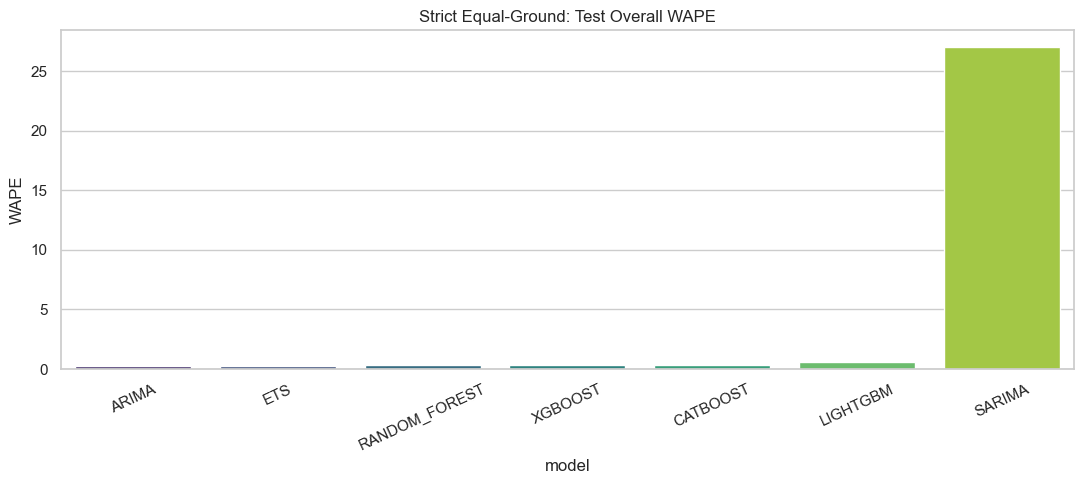

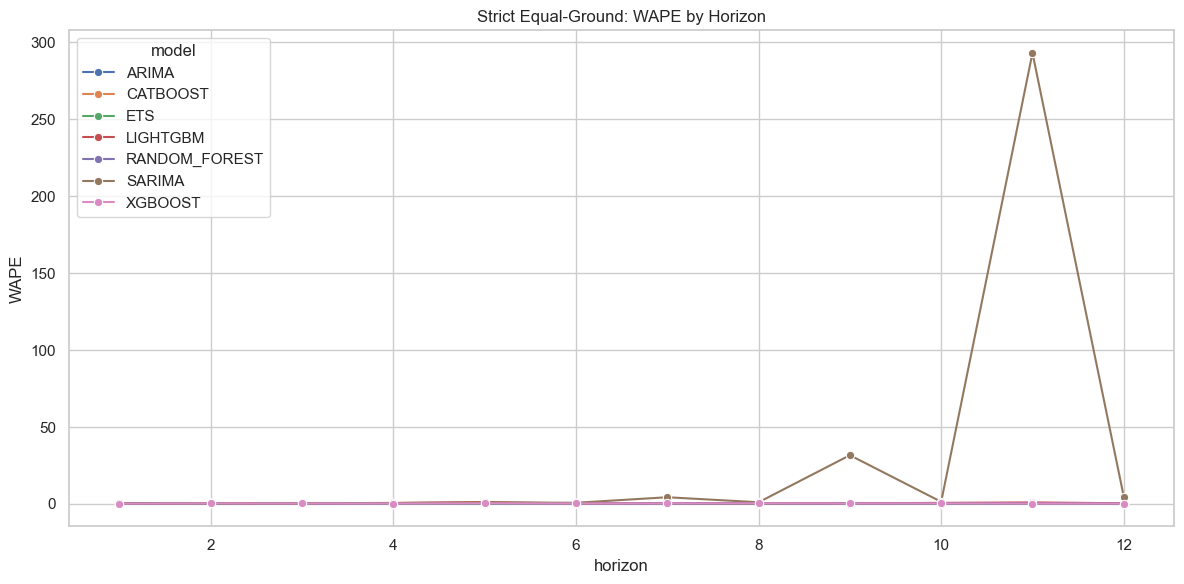

In [4]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(11, 5))
sns.barplot(data=strict_overall, x='model', y='WAPE', palette='viridis')
plt.title('Strict Equal-Ground: Test Overall WAPE')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

h = strict_metrics[strict_metrics['horizon'] > 0].copy()
plt.figure(figsize=(12, 6))
sns.lineplot(data=h, x='horizon', y='WAPE', hue='model', marker='o')
plt.title('Strict Equal-Ground: WAPE by Horizon')
plt.tight_layout()
plt.show()

In [5]:
winner = strict_overall.iloc[0]
winner_model = winner['model']

decision_rows = []
for _, r in strict_overall.iterrows():
    model = r['model']
    if model == winner_model:
        reason = 'best strict equal-ground score'
        status = 'WINNER'
    else:
        msgs = []
        if float(r['WAPE']) > float(winner['WAPE']):
            msgs.append(f"higher WAPE ({r['WAPE']:.6f} > {winner['WAPE']:.6f})")
        if float(r['RMSE']) > float(winner['RMSE']):
            msgs.append('higher RMSE')
        if abs(float(r['Bias'])) > abs(float(winner['Bias'])):
            msgs.append('higher absolute bias')
        if float(r['MASE_mean']) > float(winner['MASE_mean']):
            msgs.append('higher MASE_mean')
        reason = '; '.join(msgs) if msgs else 'not top ranked'
        status = 'REJECTED'
    decision_rows.append({'model': model, 'status': status, 'reason': reason})

decision = pd.DataFrame(decision_rows)
decision

,model,status,reason
0,ARIMA,WINNER,best strict equal-ground score
1,ETS,REJECTED,higher WAPE (0.289864 > 0.269123); higher RMSE...
2,RANDOM_FOREST,REJECTED,higher WAPE (0.309468 > 0.269123); higher RMSE...
3,XGBOOST,REJECTED,higher WAPE (0.333855 > 0.269123); higher RMSE...
4,CATBOOST,REJECTED,higher WAPE (0.351245 > 0.269123); higher RMSE...
5,LIGHTGBM,REJECTED,higher WAPE (0.561518 > 0.269123); higher RMSE...
6,SARIMA,REJECTED,higher WAPE (27.073855 > 0.269123); higher RMS...


In [6]:
strict_overall_path = REPORTS / 'portable_fair_play_strict_overall.csv'
strict_by_h_path = REPORTS / 'portable_fair_play_strict_by_horizon.csv'
decision_path = REPORTS / 'portable_fair_play_strict_decision.csv'

strict_overall.to_csv(strict_overall_path, index=False)
strict_metrics.to_csv(strict_by_h_path, index=False)
decision.to_csv(decision_path, index=False)

print('STRICT WINNER:', winner_model)
print('WAPE:', round(float(winner['WAPE']), 6))
print('RMSE:', round(float(winner['RMSE']), 3))
print('MASE_mean:', round(float(winner['MASE_mean']), 6))
print('Saved:', strict_overall_path)
print('Saved:', strict_by_h_path)
print('Saved:', decision_path)

STRICT WINNER: ARIMA
WAPE: 0.269123
RMSE: 2745.101
MASE_mean: 0.971265
Saved: /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/portable_fair_play_strict_overall.csv
Saved: /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/portable_fair_play_strict_by_horizon.csv
Saved: /Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/outputs/reports/portable_fair_play_strict_decision.csv
